In [558]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sci
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import classification_report

In [559]:
df_train = pd.read_csv('../csv_files/original_data/train.csv')
df_test = pd.read_csv('../csv_files/original_data/test.csv')


In [560]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [561]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [562]:
mean_age_train = df_train['Age'].mean()
df_train.loc[df_train['Age'].isna(), 'Age'] = mean_age_train

#We cannot perform analysis on the test data, so we fill null test values with training data
df_test.loc[df_test['Age'].isna(), 'Age'] = mean_age_train


In [563]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [564]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [565]:
#we need to fill the test fare with the mean values from the training fare set

mean_fare_train = df_train['Fare'].mean()
df_test.loc[df_test['Fare'].isna(), 'Fare'] = mean_fare_train

df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [566]:
#Change nominal data to numerical
df_train = pd.get_dummies(df_train, columns=['Sex'], dtype=int, drop_first=True)

#Appply same changse to test dataset'
df_test = pd.get_dummies(df_test, columns=['Sex'], dtype=int, drop_first=True)
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Sex_male     891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [567]:
#Now investigate SibSp attribute

unique_SibSp_values = set(df_train['SibSp'].unique())
unique_SibSp_test_values = set(df_test['SibSp'].unique())


union_SibSp_values = unique_SibSp_values.union(unique_SibSp_test_values)

print(union_SibSp_values)

{0, 1, 2, 3, 4, 5, 8}


In [568]:
# Sibsp has 7 different classifications

In [569]:
# Noww investigate Parch attribute

unique_Parch_values = set(df_train['Parch'].unique())
unique_Parch_test_values = set(df_test['Parch'].unique())

union_SibSp_values = unique_SibSp_values.union(unique_SibSp_test_values)
print(union_SibSp_values)

{0, 1, 2, 3, 4, 5, 8}


In [570]:
# 7 different categorires

In [571]:
# Now make discoveries about Cabin attribute
# Since most values are null we can change the cabin value for a binary attribute for better results


df_train['Has_Cabin'] = df_train['Cabin'].notnull().astype(int)

df_test['Has_Cabin'] = df_test['Cabin'].notnull().astype(int)


In [572]:
# Now make discoveries about Embarkation Point with respect to survial rate
df_train = pd.get_dummies(df_train, columns=['Embarked'], dtype=int)
df_test = pd.get_dummies(df_test, columns=['Embarked'], dtype=int)



In [573]:
# Now investigate Fare attribute

min_fare = df_train['Fare'].min()
max_fare = df_train['Fare'].max()

mean = df_train['Fare'].mean()
median = df_train['Fare'].median()
mode = df_train['Fare'].mode()

mad_mean = (df_train['Fare'] - df_train['Fare'].mean()).abs().mean()
mad_median = (df_train['Fare'] - df_train['Fare'].median()).abs().median()
std = df_train['Fare'].std()

print(f"Minimum Fare: {min_fare}")
print(f"Maximum Fare: {max_fare}")
print(f"Mean Fare: {mean}")
print(f"Median Fare: {median}")
print(f"Mode Fare: {mode}")
print(f"std Fare: {std}")
print(f"mad_mean Fare: {mad_mean}")
print(f"mad_median Fare: {mad_median}")


Minimum Fare: 0.0
Maximum Fare: 512.3292
Mean Fare: 32.204207968574636
Median Fare: 14.4542
Mode Fare: 0    8.05
Name: Fare, dtype: float64
std Fare: 49.6934285971809
mad_mean Fare: 28.163691848778342
mad_median Fare: 6.9042


In [574]:
# New Insights: Fare data skewed right

In [575]:
# Now investigate Age attribute

min_Age = df_train['Age'].min()
max_Age = df_train['Age'].max()

mean = df_train['Age'].mean()
median = df_train['Age'].median()
mode = df_train['Age'].mode()

mad_mean = (df_train['Age'] - df_train['Age'].mean()).abs().mean()
mad_median = (df_train['Age'] - df_train['Age'].median()).abs().median()
std = df_train['Age'].std()

print(f"Minimum Age: {min_Age}")
print(f"Maximum Age: {max_Age}")
print(f"Mean Age: {mean}")
print(f"Median Age: {median}")
print(f"Mode Age: {mode}")
print(f"std Age: {std}")
print(f"mad_mean Age: {mad_mean}")
print(f"mad_median Age: {mad_median}")


Minimum Age: 0.42
Maximum Age: 80.0
Mean Age: 29.69911764705882
Median Age: 29.69911764705882
Mode Age: 0    29.699118
Name: Age, dtype: float64
std Age: 13.002015226002884
mad_mean Age: 9.073605334389647
mad_median Age: 6.30088235294118


In [576]:
# New Insights: Age data is normally distributed

In [577]:
# create new df with the dropped attributes
df_train_dropped = df_train[['PassengerId', 'Name', 'Ticket', 'Cabin']]
df_test_dropped = df_test[['PassengerId', 'Name', 'Ticket', 'Cabin']]

#drop the attributes
df_train = df_train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df_test = df_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)


In [578]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    int64  
 7   Has_Cabin   891 non-null    int64  
 8   Embarked_C  891 non-null    int64  
 9   Embarked_Q  891 non-null    int64  
 10  Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


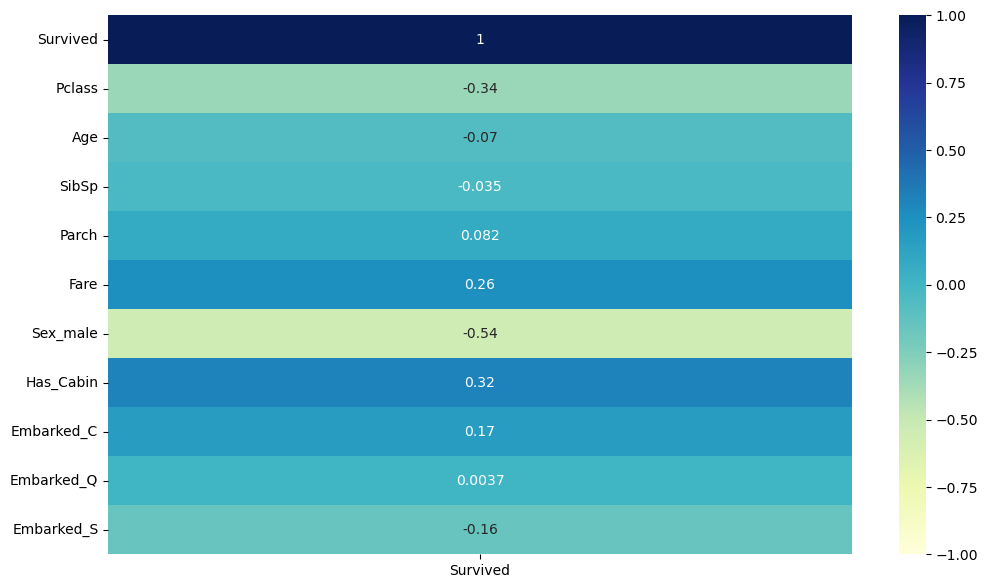

In [579]:
corr_matrix = df_train.corr()
plt.figure(figsize=(12, 7))
corr_survived = corr_matrix[['Survived']]
sns.heatmap(corr_survived, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()

In [585]:
df_train.to_csv('../csv_files/cleaned_data/train_data_cleaned.csv', index=False)

df_test.to_csv('../csv_files/cleaned_data/test_data_cleaned.csv', index=False)
df_test_dropped.to_csv('../csv_files/cleaned_data/df_test_dropped.csv', index=False)
